In [17]:
import tifffile as tif
import numpy as np

In [18]:
im = '544-56-1024-571'

im_dapi = tif.imread(f'083427/{im}-DAPI.tif')
im_cy5 = tif.imread(f'083427/{im}-CY5.tif')
im_fitc = tif.imread(f'083427/{im}-FITC.tif')
im_tritc = tif.imread(f'083427/{im}-TRITC.tif')

image = np.zeros((4, im_dapi.shape[0], im_dapi.shape[1]), dtype=np.uint16)

image[0,:,:] = im_dapi
image[1,:,:] = im_tritc
image[2,:,:] = im_cy5
image[3,:,:] = im_fitc




In [19]:
import matplotlib.pyplot as plt

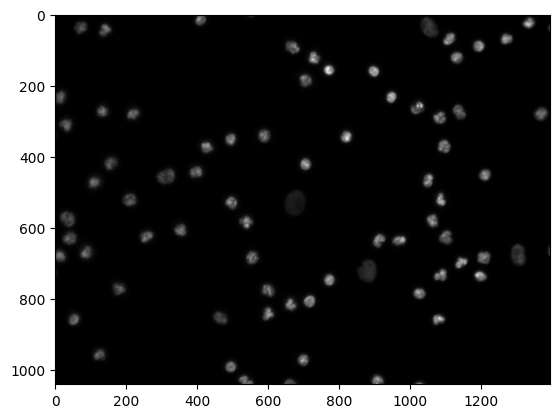

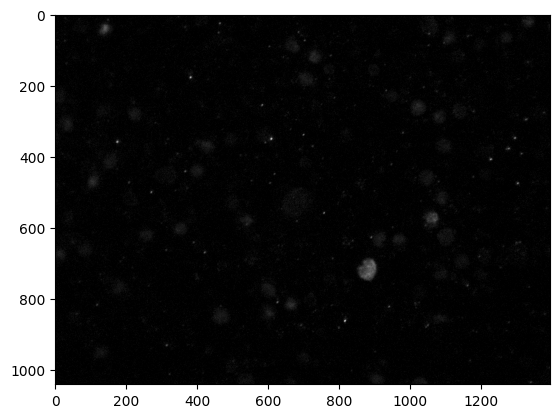

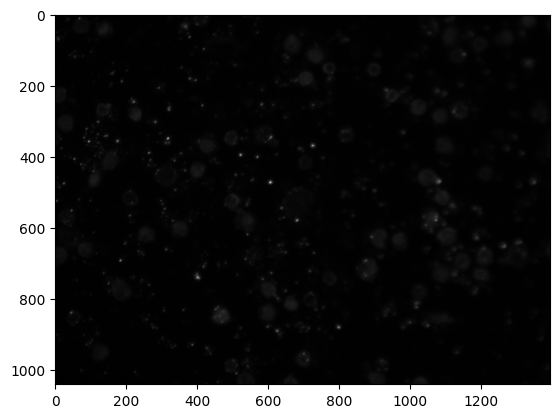

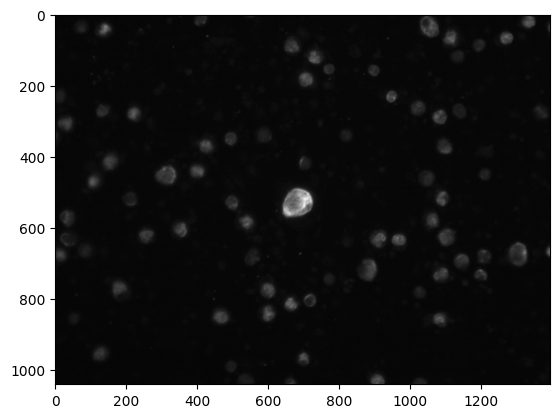

In [20]:
plt.imshow(image[0,:,:], cmap='gray')
plt.show()
plt.imshow(image[1,:,:], cmap='gray')
plt.show()
plt.imshow(image[2,:,:], cmap='gray')
plt.show()
plt.imshow(image[3,:,:], cmap='gray')
plt.show()

In [14]:
print(image[0,:,:].dtype)

uint16


180.0


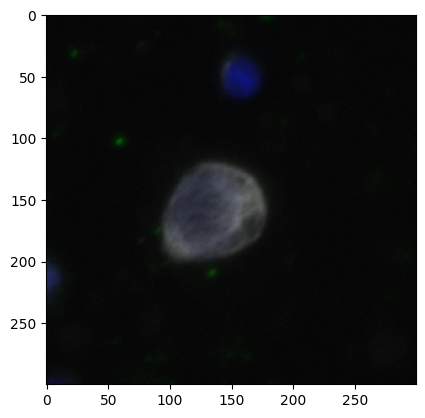

In [27]:
rgb_composite = np.zeros((image.shape[1], image.shape[2], 3), dtype=np.float32)

rgb_composite[:,:,0] = image[1,:,:].astype(np.float32)*0.5 + image[3,:,:].astype(np.float32)*3
rgb_composite[:,:,1] = image[2,:,:].astype(np.float32)*0.5 + image[3,:,:].astype(np.float32)*3
rgb_composite[:,:,2] = image[0,:,:].astype(np.float32)*2 + image[3,:,:].astype(np.float32)*3



print(rgb_composite.max())

rgb_composite = np.clip(rgb_composite, 0, 255).astype(np.uint8)

#crop to the center 150 x 150

rgb_composite = rgb_composite[rgb_composite.shape[0]//2-150:rgb_composite.shape[0]//2+150, rgb_composite.shape[1]//2-150:rgb_composite.shape[1]//2+150, :]

plt.imshow(rgb_composite)